In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/repos_clean.csv")
df.shape

(2397, 19)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2397 entries, 0 to 2396
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       2397 non-null   int64  
 1   full_name                2397 non-null   object 
 2   created_at               2397 non-null   object 
 3   pushed_at                2397 non-null   object 
 4   stargazers_count         2397 non-null   int64  
 5   forks_count              2397 non-null   int64  
 6   has_license              2397 non-null   bool   
 7   has_wiki                 2397 non-null   bool   
 8   has_description          2397 non-null   bool   
 9   first_month_commits      2397 non-null   int64  
 10  contributors_count       2397 non-null   int64  
 11  open_issues              2397 non-null   int64  
 12  closed_issues            2397 non-null   int64  
 13  age_days                 2397 non-null   int64  
 14  days_since_push         

In [3]:
df.describe()

,id,stargazers_count,forks_count,first_month_commits,contributors_count,open_issues,closed_issues,age_days,days_since_push,issue_close_ratio,commits_per_contributor,label,has_traction
count,2.397000e+03,2397.000000,2397.000000,2397.000000,2397.000000,2397.000000,2397.000000,2397.000000,2397.000000,2397.000000,2397.000000,2397.000000,2397.000000
mean,7.438087e+08,4166.551940,535.856070,39.617021,18.446809,42.600751,138.984147,971.033375,548.482687,0.347240,8.371233,0.310388,0.679182
std,9.387916e+07,12689.168984,1955.372736,111.438950,54.965046,169.570910,680.105744,210.083491,421.822813,0.378157,20.226419,0.462749,0.466888
min,5.840566e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,609.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.605513e+08,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,794.000000,75.000000,0.000000,1.000000,0.000000,0.000000
50%,7.373911e+08,49.000000,6.000000,10.000000,2.000000,1.000000,1.000000,976.000000,611.000000,0.208333,3.000000,0.000000,1.000000
75%,8.219797e+08,3956.000000,376.000000,36.000000,8.000000,21.000000,41.000000,1160.000000,905.000000,0.690000,8.565217,1.000000,1.000000
max,9.105671e+08,187075.000000,46044.000000,2540.000000,474.000000,4182.000000,15822.000000,1340.000000,1316.000000,1.000000,635.000000,1.000000,1.000000


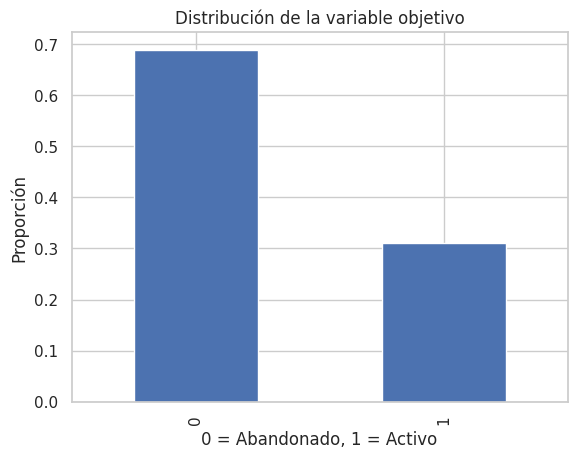

In [4]:
df["label"].value_counts(normalize=True).plot(kind="bar", title="Distribución de la variable objetivo")
plt.xlabel("0 = Abandonado, 1 = Activo")
plt.ylabel("Proporción")
plt.show()

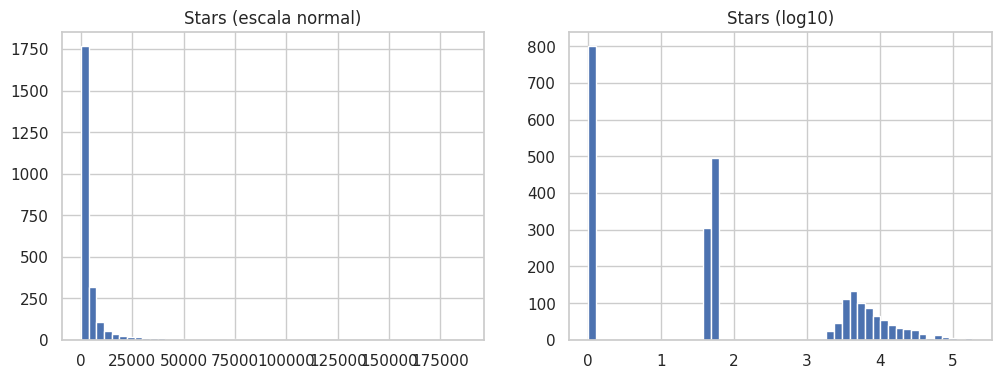

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["stargazers_count"].hist(bins=50, ax=axes[0])
axes[0].set_title("Stars (escala normal)")

df["stargazers_count"].apply(lambda x: x if x == 0 else __import__("math").log10(x)).hist(bins=50, ax=axes[1])
axes[1].set_title("Stars (log10)")
plt.show()

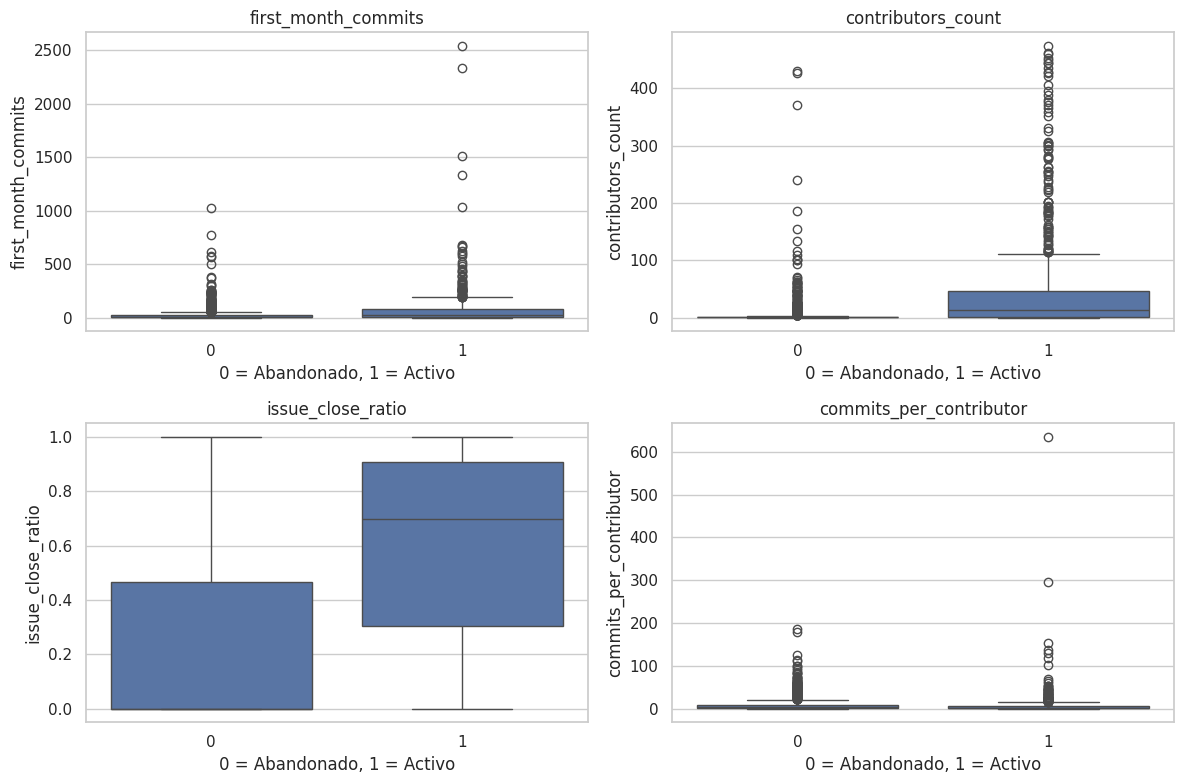

In [6]:
features_to_compare = ["first_month_commits", "contributors_count", "issue_close_ratio", "commits_per_contributor"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feature in zip(axes.flatten(), features_to_compare):
    sns.boxplot(data=df, x="label", y=feature, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("0 = Abandonado, 1 = Activo")
plt.tight_layout()
plt.show()

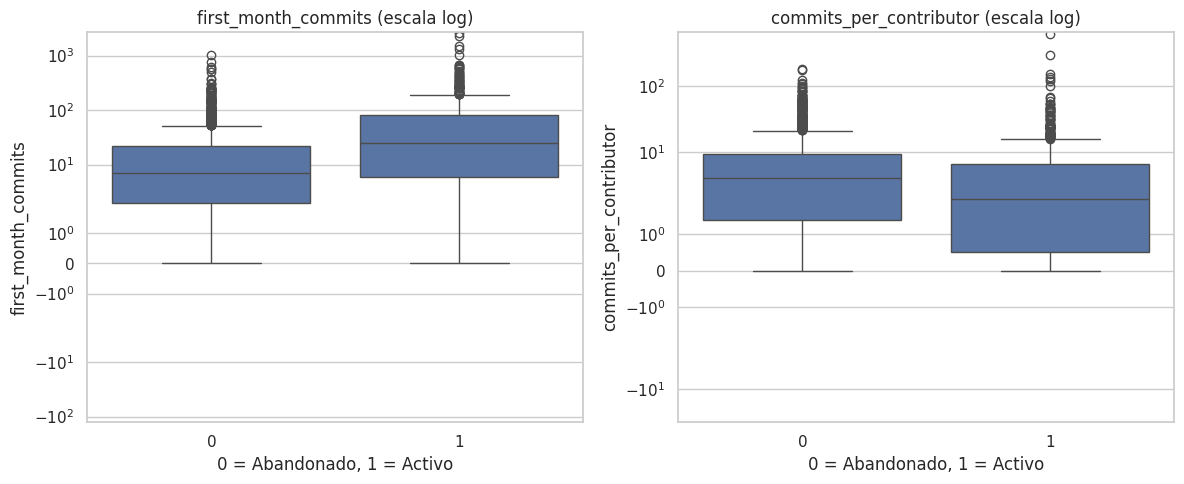

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x="label", y="first_month_commits", ax=axes[0])
axes[0].set_yscale("symlog")  # symlog porque hay ceros, log puro no admite 0
axes[0].set_title("first_month_commits (escala log)")
axes[0].set_xlabel("0 = Abandonado, 1 = Activo")

sns.boxplot(data=df, x="label", y="commits_per_contributor", ax=axes[1])
axes[1].set_yscale("symlog")
axes[1].set_title("commits_per_contributor (escala log)")
axes[1].set_xlabel("0 = Abandonado, 1 = Activo")

plt.tight_layout()
plt.show()

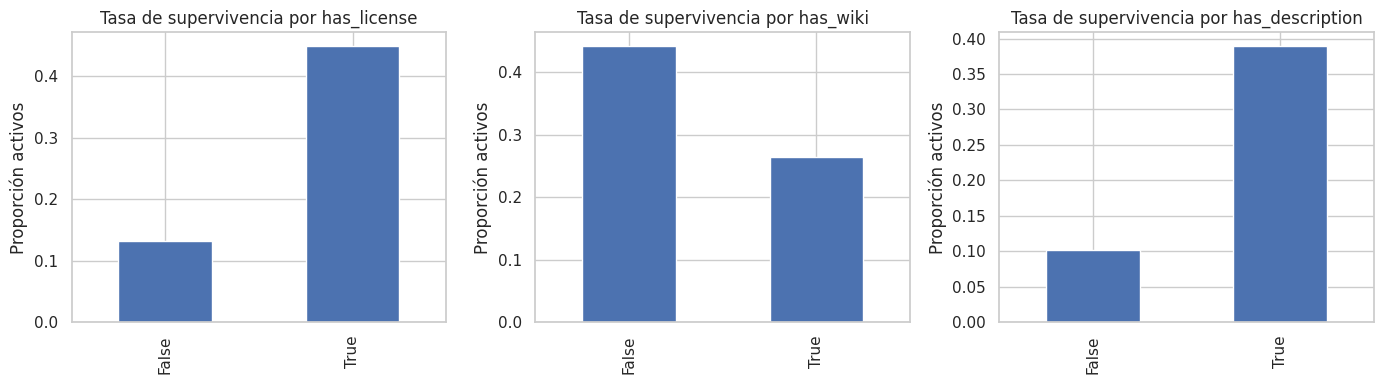

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["has_license", "has_wiki", "has_description"]):
    survival_rate = df.groupby(col)["label"].mean()
    survival_rate.plot(kind="bar", ax=ax)
    ax.set_title(f"Tasa de supervivencia por {col}")
    ax.set_ylabel("Proporción activos")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

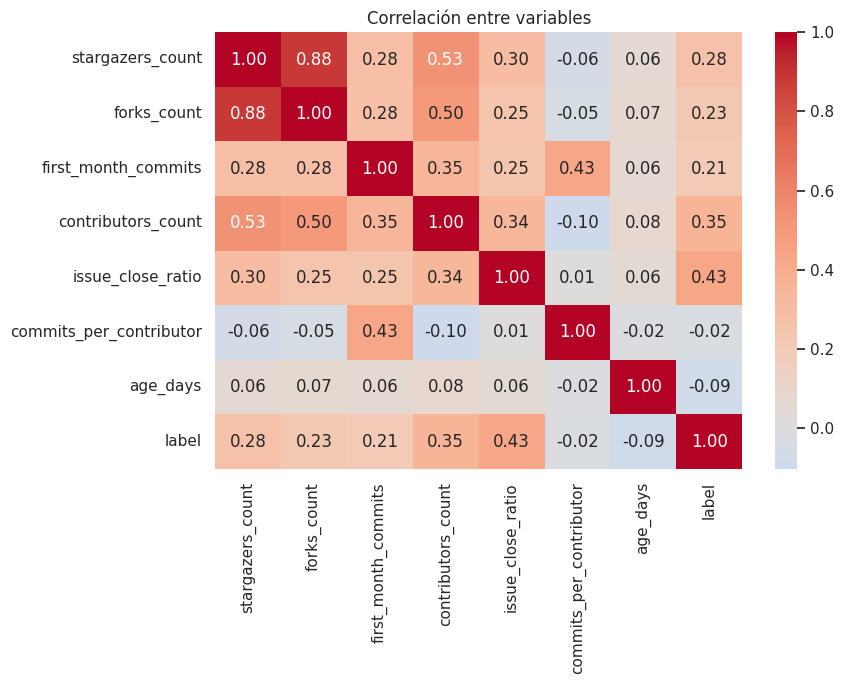

In [9]:
numeric_cols = ["stargazers_count", "forks_count", "first_month_commits", "contributors_count",
                 "issue_close_ratio", "commits_per_contributor", "age_days", "label"]

plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre variables")
plt.tight_layout()
plt.show()

In [15]:
!pip install scikit-learn

In [16]:
from sklearn.model_selection import train_test_split

feature_cols = [
    "stargazers_count", "forks_count", "first_month_commits", "contributors_count",
    "issue_close_ratio", "commits_per_contributor", "age_days",
    "has_license", "has_wiki", "has_description",
]

X = df[feature_cols]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train balance:", y_train.value_counts(normalize=True).to_dict())
print("Test balance:", y_test.value_counts(normalize=True).to_dict())

Train: (1917, 10) | Test: (480, 10)
Train balance: {0: 0.6896191966614502, 1: 0.31038080333854984}
Test balance: {0: 0.6895833333333333, 1: 0.3104166666666667}


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(class_weight="balanced", n_estimators=200, random_state=42)
rf.fit(X_train, y_train)  # Random Forest no necesita escalado

print("Models trained")

Models trained


In [19]:
from sklearn.metrics import classification_report, roc_auc_score

# Logistic Regression uses scaled data
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"\n{'='*50}\nLogistic Regression\n{'='*50}")
print(classification_report(y_test, y_pred_lr, target_names=["Abandoned", "Active"]))
print(f"AUC: {roc_auc_score(y_test, y_proba_lr):.3f}")

# Random Forest uses unscaled data
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(f"\n{'='*50}\nRandom Forest\n{'='*50}")
print(classification_report(y_test, y_pred_rf, target_names=["Abandoned", "Active"]))
print(f"AUC: {roc_auc_score(y_test, y_proba_rf):.3f}")


Logistic Regression
              precision    recall  f1-score   support

   Abandoned       0.86      0.70      0.77       331
      Active       0.52      0.74      0.61       149

    accuracy                           0.71       480
   macro avg       0.69      0.72      0.69       480
weighted avg       0.75      0.71      0.72       480

AUC: 0.802

Random Forest
              precision    recall  f1-score   support

   Abandoned       0.84      0.88      0.86       331
      Active       0.71      0.64      0.67       149

    accuracy                           0.81       480
   macro avg       0.78      0.76      0.77       480
weighted avg       0.80      0.81      0.80       480

AUC: 0.851


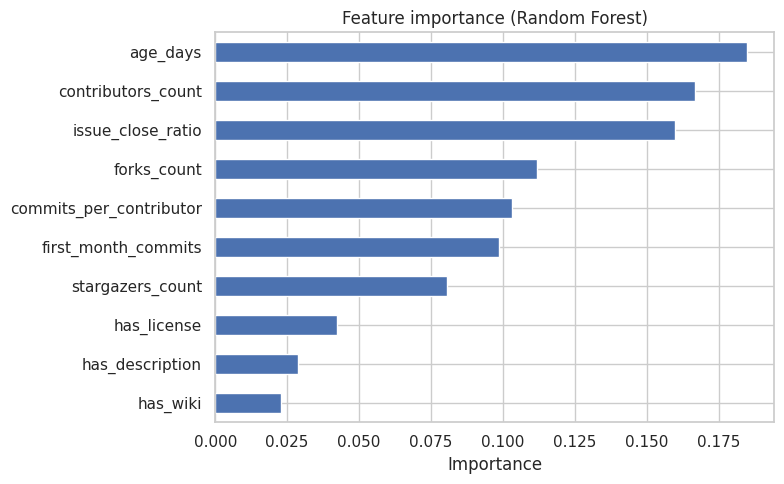

age_days                   0.185033
contributors_count         0.166729
issue_close_ratio          0.159898
forks_count                0.112017
commits_per_contributor    0.103201
first_month_commits        0.098576
stargazers_count           0.080424
has_license                0.042458
has_description            0.028834
has_wiki                   0.022829
dtype: float64

In [20]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.title("Feature importance (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importances

In [21]:
feature_cols_v2 = [c for c in feature_cols if c != "age_days"]

X2 = df[feature_cols_v2]
X2_train, X2_test, y_train2, y_test2 = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)

rf2 = RandomForestClassifier(class_weight="balanced", n_estimators=200, random_state=42)
rf2.fit(X2_train, y_train2)

y_pred2 = rf2.predict(X2_test)
y_proba2 = rf2.predict_proba(X2_test)[:, 1]

print(classification_report(y_test2, y_pred2, target_names=["Abandoned", "Active"]))
print(f"AUC without age_days: {roc_auc_score(y_test2, y_proba2):.3f}")

              precision    recall  f1-score   support

   Abandoned       0.85      0.85      0.85       331
      Active       0.67      0.66      0.66       149

    accuracy                           0.79       480
   macro avg       0.76      0.75      0.76       480
weighted avg       0.79      0.79      0.79       480

AUC without age_days: 0.817


In [22]:
import joblib
import os

os.makedirs("../src/model", exist_ok=True)
joblib.dump(rf2, "../src/model/repo_survival_model.pkl")
joblib.dump(feature_cols_v2, "../src/model/feature_cols.pkl")

print("Model saved")

Model saved
